In [1]:
import torch, sbi
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("sbi:", sbi.__version__)

torch: 2.5.1+cpu
CUDA available: False
sbi: 0.25.0


In [2]:
from sbi.examples.minimal import simple
posterior = simple()
print(posterior)

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


  0%|          | 0/500 [00:00<?, ?it/s]

 Neural network successfully converged after 97 epochs.

  0%|          | 0/100 [00:00<?, ?it/s]

Posterior p(θ|x) of type DirectPosterior. It samples the posterior network and rejects samples that
            lie outside of the prior bounds.


### Working through Tutorial

In [ ]:
import torch
from sbi.utils import BoxUniform
from sbi.inference import NPE
from sbi.analysis import pairplot

_ = torch.manual_seed(0)

num_dim = 3
prior = BoxUniform(low=-2 * torch.ones(num_dim), high=2 * torch.ones(num_dim))

def simulator(theta): # i think this is the likelihood
    # Linear Gaussian.
    return theta + 1.0 + torch.randn_like(theta) * 0.1

num_simulations = 1000
theta = prior.sample((num_simulations,))
x = simulator(theta)
print("theta.shape", theta.shape)
print("x.shape", x.shape)



theta.shape torch.Size([1000, 3])
x.shape torch.Size([1000, 3])


 Neural network successfully converged after 132 epochs.Posterior p(θ|x) of type DirectPosterior. It samples the posterior network and rejects samples that
            lie outside of the prior bounds.


  0%|          | 0/10000 [00:00<?, ?it/s]

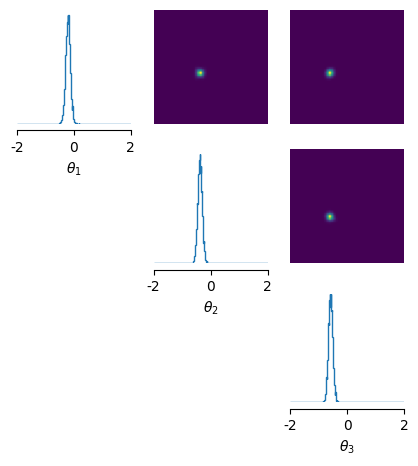

In [ ]:

inference = NPE(prior=prior) # inerence is a class, you're setting up the method

inference = inference.append_simulations(theta, x) # now provide the dataset
density_estimator = inference.train() # now call the method training the model (this is using alg in notes i guess)
posterior = inference.build_posterior() # wraps trained neural density estimator into callable prob dist^n  - how
print(posterior)

x_obs = torch.as_tensor([0.8, 0.6, 0.4])
samples = posterior.sample((10000,), x=x_obs)

_ = pairplot(
    samples,
    limits=[[-2, 2], [-2, 2], [-2, 2]],
    figsize=(5, 5),
    labels=[r"$\theta_1$", r"$\theta_2$", r"$\theta_3$"]
)


In [6]:
theta_posterior = posterior.sample((10000,), x=x_obs)  # Sample from posterior.
x_predictive = simulator(theta_posterior)  # Simulate data from posterior.

print("Posterior predictives: ", torch.mean(x_predictive, axis=0))
print("Observation: ", x_obs)

  0%|          | 0/10000 [00:00<?, ?it/s]

Posterior predictives:  tensor([0.7888, 0.6191, 0.4078])
Observation:  tensor([0.8000, 0.6000, 0.4000])


### **Experimenting with Diagnostics**

    Expected Coverage

Sampling 200 times (1000,) posterior samples.: 100%|██████████| 200/200 [00:14<00:00, 13.35it/s]


Calculating ranks for 200 SBC samples:   0%|          | 0/200 [00:00<?, ?it/s]

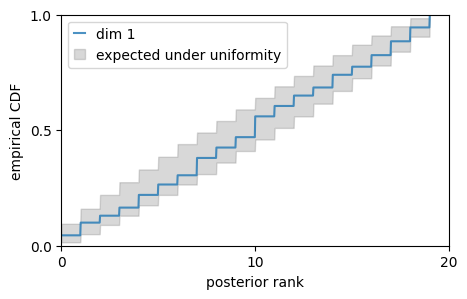

In [7]:
from sbi.diagnostics import run_sbc
from sbi.analysis.plot import sbc_rank_plot

num_sbc_samples = 200  # choose a number of sbc runs, should be ~100s
prior_samples = prior.sample((num_sbc_samples,))
prior_predictives = simulator(prior_samples)

# run SBC: for each inference we draw 1000 posterior samples.
num_posterior_samples = 1_000
ranks, dap_samples = run_sbc(
    prior_samples,
    prior_predictives,
    posterior,
    reduce_fns=lambda theta, x: -posterior.log_prob(theta, x),
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False,  # `True` can give speed-ups, but can cause memory issues.
)
fig, ax = sbc_rank_plot(
    ranks,
    num_posterior_samples,
    plot_type="cdf",
    num_bins=20,
    figsize=(5, 3),
)

SBC - this is very similar to above (only two lines change in code). necessary but not sufficient test, shows if marginals of posterior too wide/narrow/skewewd. Note we don't do reduce function so now get three graphs below. 

Sampling 200 times (1000,) posterior samples.:   0%|          | 0/200 [00:00<?, ?it/s]

Sampling 200 times (1000,) posterior samples.: 100%|██████████| 200/200 [00:11<00:00, 17.74it/s]


Calculating ranks for 200 SBC samples:   0%|          | 0/200 [00:00<?, ?it/s]

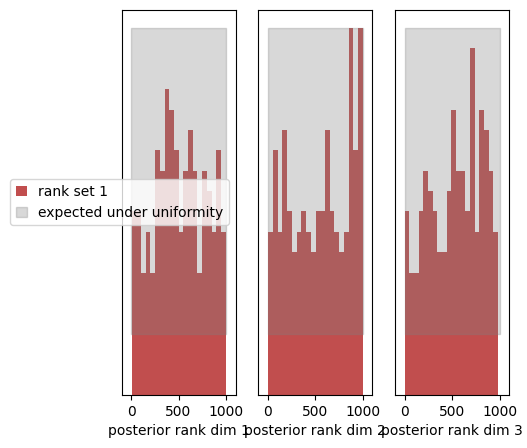

In [12]:
num_sbc_samples2 = 200  # choose a number of sbc runs, should be ~100s
prior_samples2 = prior.sample((num_sbc_samples2,))
prior_predictives2 = simulator(prior_samples2)

# run SBC: for each inference we draw 1000 posterior samples.
num_posterior_samples2 = 1_000
ranks2, dap_samples2 = run_sbc(
    prior_samples2,
    prior_predictives2,
    posterior,
    num_posterior_samples=num_posterior_samples2,
    use_batched_sampling=False,  # `True` can give speed-ups, but can cause memory issues.
)
fig2, ax2 = sbc_rank_plot(
    ranks2,
    num_posterior_samples2,
    plot_type="hist",
    num_bins=20,
    figsize=(5, 5),
)